In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('mouse_viral_study.csv')

In [5]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


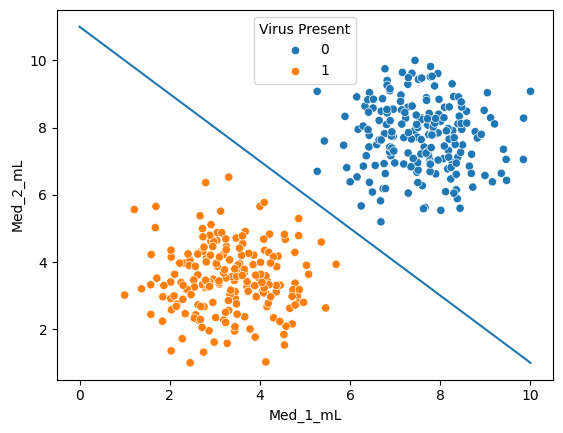

In [11]:
sns.scatterplot(data=df, x='Med_1_mL', y='Med_2_mL', hue='Virus Present')
# HYPERPLANE (2d line)

x = np.linspace(0, 10, 100)

m = -1
b=11

y = m*x + b

plt.plot(x, y) #creating a seperating hyperplane 

In [12]:
from sklearn.svm import SVC

In [13]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(
 |      *,
 |      C=1.0,
 |      kernel='rbf',
 |      degree=3,
 |      gamma='scale',
 |      coef0=0.0,
 |      shrinking=True,
 |      probability=False,
 |      tol=0.001,
 |      cache_size=200,
 |      class_weight=None,
 |      verbose=False,
 |      max_iter=-1,
 |      decision_function_shape='ovr',
 |      break_ties=False,
 |      random_state=None
 |  )
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to a

In [14]:
y = df['Virus Present']
X = df.drop('Virus Present', axis=1)

In [15]:
model = SVC(kernel='linear', C =1000)

In [16]:
model.fit(X, y)

,C,1000
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
from svm_margin_plot import plot_svm_boundary #using a python code for this

d:\Programs\Github\data-science-concepts\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


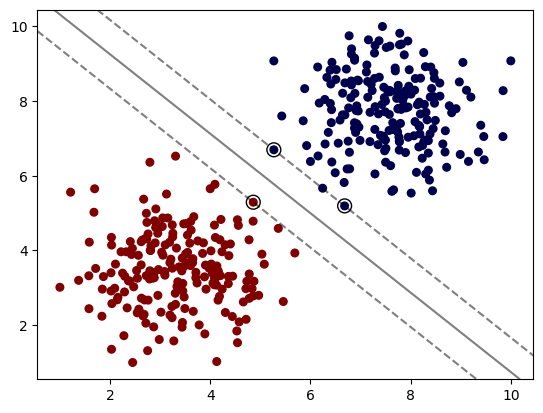

In [19]:
plot_svm_boundary(model, X, y)

In [ ]:
model = SVC(kernel='linear', C =0.005) #the c is inversly proportional to the margin
model.fit(X, y) 

,C,0.005
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


d:\Programs\Github\data-science-concepts\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


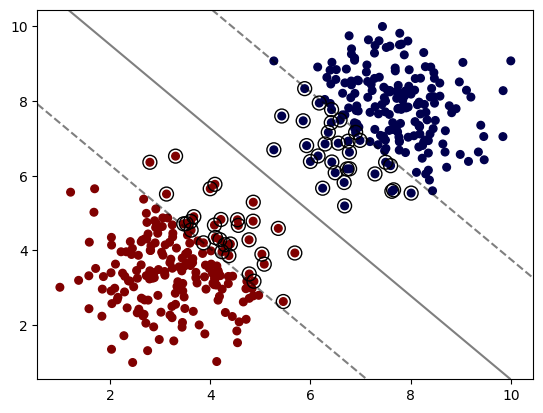

In [24]:
plot_svm_boundary(model, X, y)

d:\Programs\Github\data-science-concepts\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


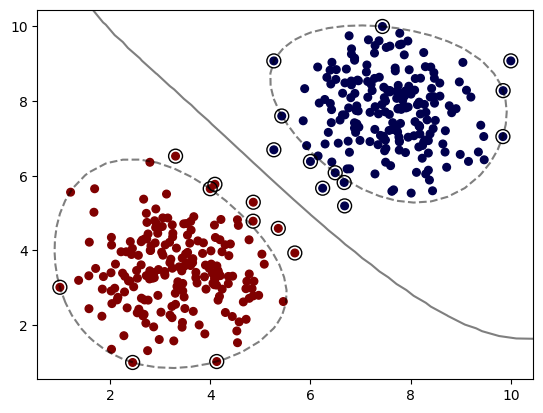

In [35]:
model = SVC(kernel='rbf', C=0.5, gamma='scale') #kernel is radial basis function, means it is no more linear
#gamma defines how much training influence a example have
model.fit(X, y)
plot_svm_boundary(model, X, y)

d:\Programs\Github\data-science-concepts\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


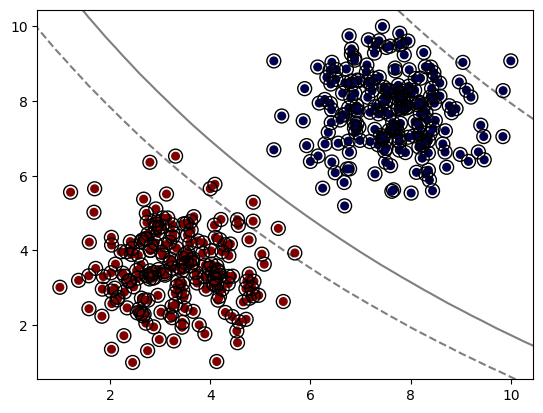

In [36]:
model = SVC(kernel='sigmoid')
model.fit(X, y)
plot_svm_boundary(model, X, y)

d:\Programs\Github\data-science-concepts\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


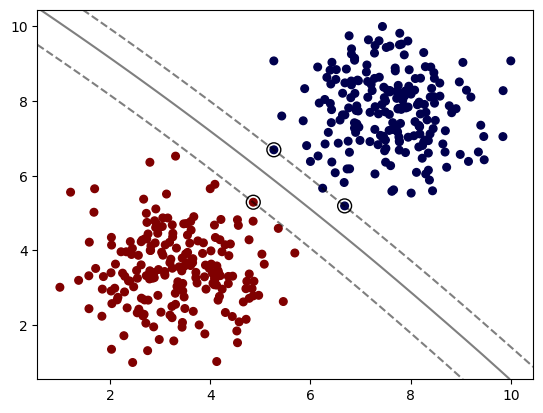

In [ ]:
model = SVC(kernel='poly', C=0.05, degree=8) 
model.fit(X, y)
plot_svm_boundary(model, X, y)

In [41]:
from sklearn.model_selection import GridSearchCV

In [46]:
svm = SVC()
param_grid = {'C': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf', 'sigmoid', 'poly']}

In [47]:
grid = GridSearchCV(svm, param_grid)

In [48]:
grid.fit(X, y)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [ ]:
grid.best_params_ #finding the best parameters

{'C': 0.01, 'kernel': 'linear'}